Data Cleaning & Preprocessing

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import emoji
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import opinion_lexicon
import unicodedata
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
import string
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('opinion_lexicon')


# Show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Adjust width to avoid truncation
pd.set_option('display.max_colwidth', None)  # Show full column content

c:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


Loading data into dataframe

In [2]:
df = pd.read_csv("../data/raw/Sentiment_Data.csv", encoding='latin1')
df.head()

,Tweet,Sentiment
0,"@_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's ""American Pie"") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy https://t.co/ZT1cIPwmh9",Mild_Pos
1,"@McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's ""American Pie"") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy https://t.co/ZT1cIPwmh9",Mild_Pos
2,"@thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's ""American Pie"") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy https://t.co/ZT1cIPwmh9",Mild_Pos
3,"@NChartierET Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's ""American Pie"") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy https://t.co/ZT1cIPwmh9",Mild_Pos
4,"@tabithapeters05 Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's ""American Pie"") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy https://t.co/ZT1cIPwmh9",Mild_Pos


Datatypes of dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451332 entries, 0 to 451331
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Tweet      451331 non-null  object
 1   Sentiment  451332 non-null  object
dtypes: object(2)
memory usage: 6.9+ MB


Shape of the dataset

In [4]:
len(df),df.index.shape[-1]

(451332, 451332)

In [5]:
print("Shape of dataset: ".format(), df.shape)

Shape of dataset:  (451332, 2)


In [6]:
mild_pos_tweet = df[df['Sentiment'] == 'Mild_Pos']['Tweet']
mild_neg_tweet = df[df['Sentiment'] == 'Mild_Neg']['Tweet']
neutral_tweet = df[df['Sentiment'] == 'Neutral']['Tweet']
strong_pos_tweet = df[df['Sentiment'] == 'Strong_Pos']['Tweet']
strong_neg_tweet = df[df['Sentiment'] == 'Strong_Neg']['Tweet']

sentiment_samples = {
    "Mild_Pos": mild_pos_tweet,
    "Mild_Neg": mild_neg_tweet,
    "Neutral": neutral_tweet,
    "Strong_Pos": strong_pos_tweet,
    "Strong_Neg": strong_neg_tweet
}

for label, series in sentiment_samples.items():
    print(f"\n{'='*10} First 5 samples of {label.replace('_', ' ').title()} tweets {'='*10}\n")
    for i, tweet in enumerate(series.head(5), 1):
        print(f"{i}. {tweet}\n")


========== First 5 samples of Mild Pos tweets ==========

1. @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

2. @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

3. @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

4. @NChartierET Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

5. @tabithapeters05 Happy Anniversary!!!....The Day the 

Helper function to plot sentiment counts

In [7]:
def plot_sentiment_counts(sentiment_counts):
    plt.rcParams['figure.figsize'] = (8, 6)
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray', 'darkgreen', 'darkred'])
    plt.xlabel('Sentiment Class')
    plt.ylabel('Number of Tweets')
    plt.title('Number of Tweets per Sentiment Class')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, int(yval), ha='center', va='bottom', fontsize=10)
    plt.show()

Total Counts of all sentiment classes:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


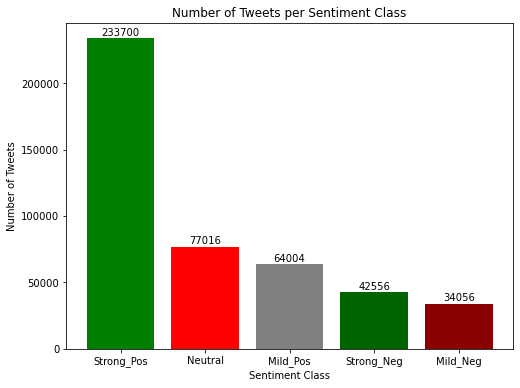

In [8]:
sentiment_counts = df['Sentiment'].value_counts()
print('Total Counts of all sentiment classes:\n', sentiment_counts)
print("==============")

plot_sentiment_counts(sentiment_counts)

Adding word count for each tweet in the dataframe

In [9]:
df['word_count'] = df['Tweet'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

Word count distribution plot

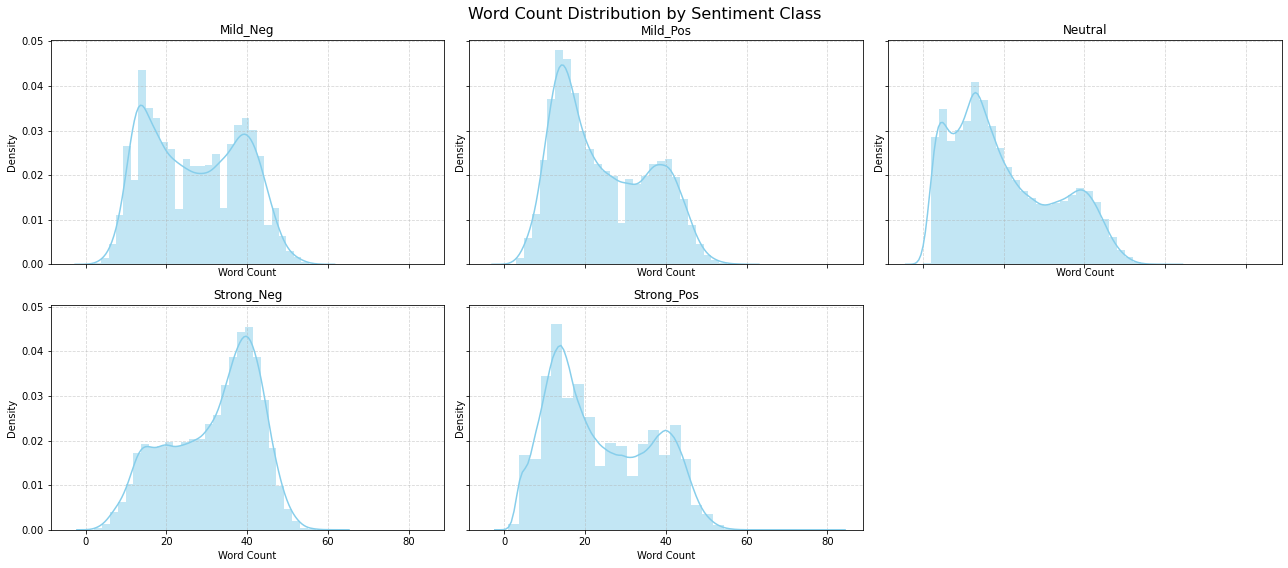

In [120]:
sentiments = sorted(df['Sentiment'].unique())

fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sentiment in enumerate(sentiments):
    word_counts = df[df['Sentiment'] == sentiment]['word_count']
    sns.distplot(word_counts, bins=30, kde=True, color="skyblue", hist_kws={"alpha":0.5}, ax=axes[idx])
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Word Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

# Hide any unused subplot (for 5 classes in 6 slots)
if len(sentiments) < len(axes):
    for idx in range(len(sentiments), len(axes)):
        axes[idx].set_visible(False)

fig.suptitle("Word Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Adding punctuation count for each tweet in the dataframe

In [121]:
df['punctuation_count'] = df['Tweet'].apply(lambda z: len([c for c in str(z) if c in string.punctuation]))

Punctuation count distribution plot

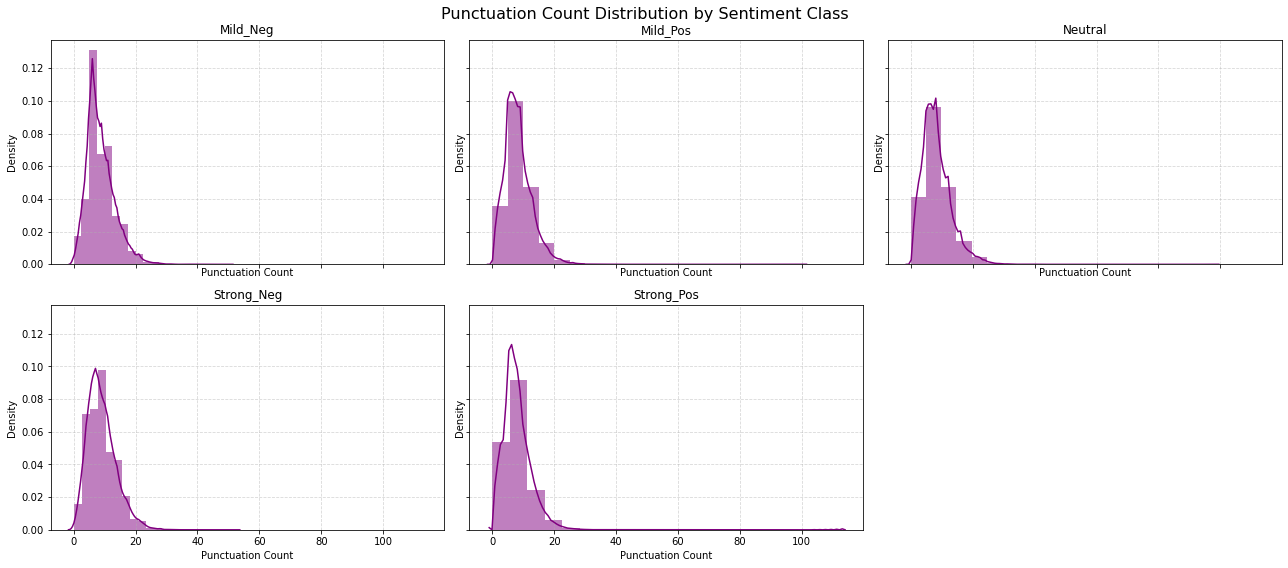

In [122]:
sentiments = sorted(df['Sentiment'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sentiment in enumerate(sentiments):
    counts = df[df['Sentiment'] == sentiment]['punctuation_count']
    sns.distplot(counts, bins=20, kde=True, color="purple", hist_kws={"alpha":0.5}, ax=axes[idx])
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Punctuation Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

for idx in range(len(sentiments), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Punctuation Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


Handling missing values

In [10]:
df.isnull().sum()

Tweet         1
Sentiment     0
word_count    0
dtype: int64

In [11]:
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)

      Tweet Sentiment  word_count
75986   NaN   Neutral           0


In [12]:
df.dropna(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451331 entries, 0 to 451331
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Tweet       451331 non-null  object
 1   Sentiment   451331 non-null  object
 2   word_count  451331 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 13.8+ MB


In [14]:
df.isnull().sum()

Tweet         0
Sentiment     0
word_count    0
dtype: int64

Helper functions to clean text

In [15]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = contractions.fix(text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r'[^\w\s-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Cleaning the tweets by replacing some irregular texts

In [16]:
df['clean_tweet'] = df['Tweet'].apply(clean_text)

In [17]:
def demojize_text(text):
    text = emoji.demojize(text, delimiters=(" ", " "))
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"  
        u"\U0001F680-\U0001F6FF"  
        u"\U0001F1E0-\U0001F1FF"  
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)
    
    emoji_count = len(emoji_pattern.findall(text))

    text = emoji_pattern.sub(r'', text)
    return text, emoji_count

Cleaning the tweets by replacing emoticons

In [18]:
df[['clean_tweet', 'emoji_count']] = df['clean_tweet'].apply(
    lambda x: pd.Series(demojize_text(x))
)

# Now get the total emoji handled
total_emoji = df['emoji_count'].sum()
print(f"Emoji Handled: {total_emoji}")

Emoji Handled: 0


In [19]:
slang_dict = {
    "idk": "i do not know",
    "brb": "be right back",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "lmao": "laughing my ass off",
    "fyi": "for your information",
    "btw": "by the way",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "ikr": "i know right",
    "ttyl": "talk to you later",
    "bff": "best friends forever",
    "afk": "away from keyboard",
    "rofl": "rolling on the floor laughing",
    "np": "no problem",
    "ftw": "for the win",
    "jk": "just kidding",
    "ppl": "people",
    "ur": "your",
    "cya": "see you",
    "thx": "thanks",
    "gr8": "great",
    "pls": "please",
    "plz": "please"
}

def replace_slang(text, slang_dict= slang_dict):
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    slang_count = sum(1 for w in words if w in slang_dict)
    return " ".join(words), slang_count


Cleaning the tweets by replacing slang words

In [20]:
df[['clean_tweet', 'slang_count']] = df['clean_tweet'].apply(
    lambda x: pd.Series(replace_slang(x))
)

total_slang = df['slang_count'].sum()
print(f"Slang Handled: {total_slang}")

Slang Handled: 0


Tokenizing the words

In [134]:
df['tokens'] = df['clean_tweet'].apply(word_tokenize)

In [135]:
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

Lemmatizing the tokens

In [136]:
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

In [137]:
df['clean_tweet'] = df['tokens'].apply((lambda x: ' '.join(x)))

In [138]:
print(df.columns)

Index(['Tweet', 'Sentiment', 'word_count', 'punctuation_count', 'clean_tweet',
       'tokens'],
      dtype='object')


Word cloud for 5 classes (Mild_Neg, Strong_Neg, Neutral, Mild_Pos, Strong_Pos)

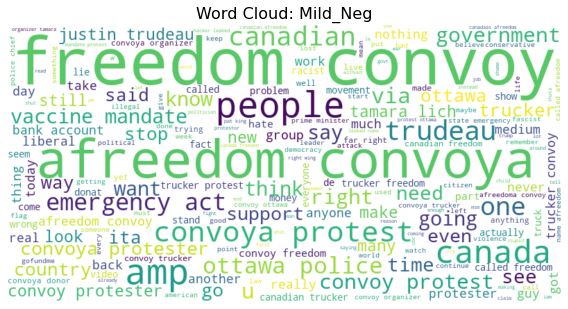

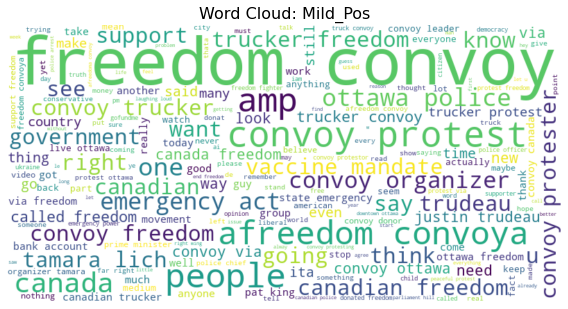

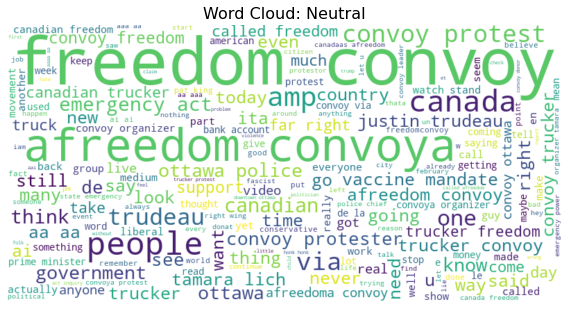

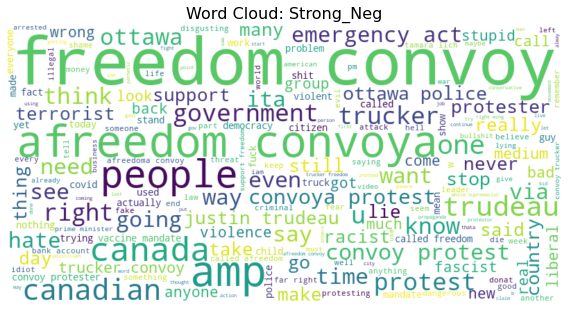

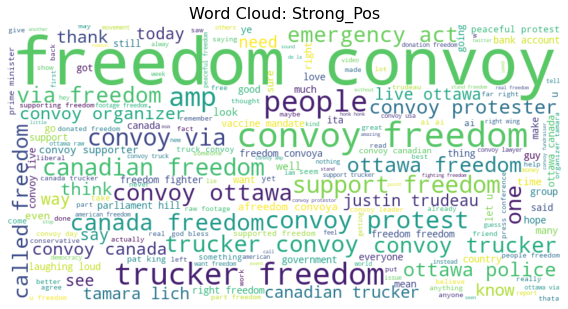

In [139]:
classes = sorted(df['Sentiment'].unique())

img_path = None

for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    if img_path is not None:
        mask = np.array(Image.open(img_path))
    else:
        mask = None
    wc = WordCloud(
        stopwords=STOPWORDS, 
        mask=mask,
        background_color="white", 
        contour_width=2, 
        contour_color="black",
        max_words=200,
        max_font_size=256,
        random_state=42,
        width=800 if mask is None else mask.shape[1],
        height=400 if mask is None else mask.shape[0]
    ).generate(' '.join(map(str, texts.dropna())))
    plt.figure(figsize=(8, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis('off')
    plt.title(f"Word Cloud: {sentiment}", fontsize=16)
    plt.tight_layout()
    plt.show()


Top 20 most frequent words for all 5 classes

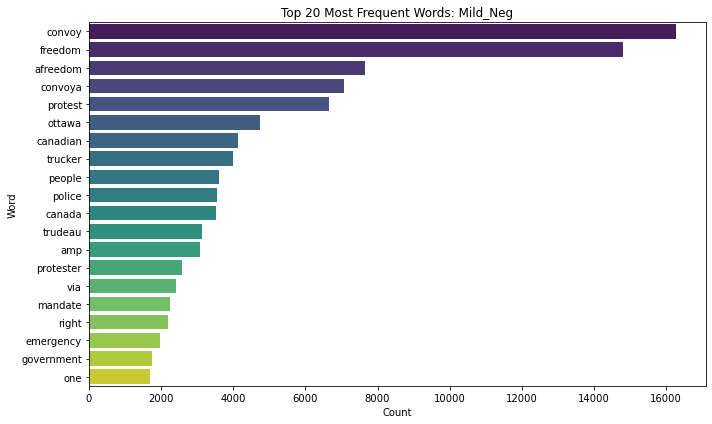

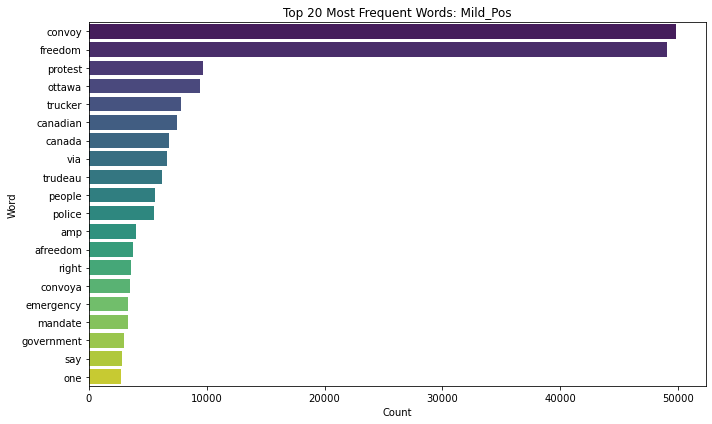

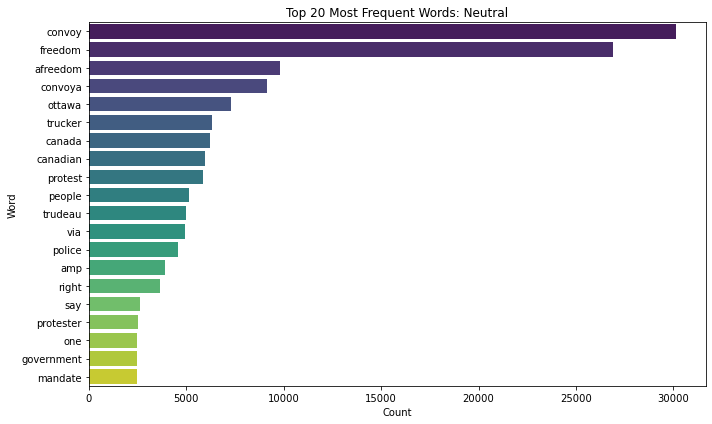

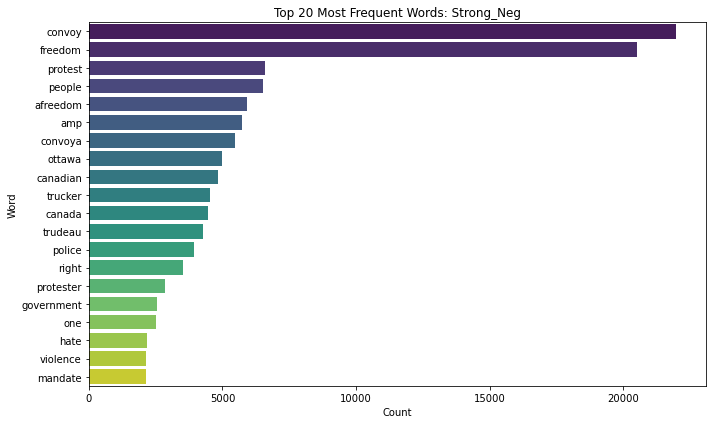

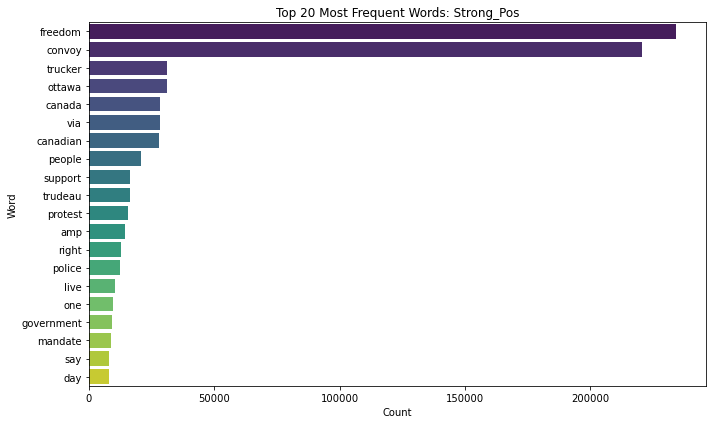

In [140]:
def plot_top_words(texts, n=20, title=None):
    words = [
        word.lower() for text in texts 
        for word in word_tokenize(text) 
        if word.lower() not in STOPWORDS and len(word) > 2 and word.isalpha()
    ]
    word_counts = Counter(words)
    top_words = word_counts.most_common(n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=[count for word, count in top_words],
        y=[word for word, count in top_words],
        palette='viridis'
    )
    plt.title(title or f'Top {n} Most Frequent Words')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

# For all classes
for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    plot_top_words(
        texts, n=20, title=f"Top 20 Most Frequent Words: {sentiment}"
    )

In [141]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
print(f"Total empty strings (after cleaning): {empt_str:,}")

Total tweets: 451,331
Total empty strings (after cleaning): 10,278


Removing the row from dataframe which has empty string after cleaning the data

In [142]:
df = df[df['clean_tweet'].str.strip().astype(bool)]

In [143]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
print(f"Total empty strings (after cleaning): {empt_str:,}")

Total tweets: 441,053
Total empty strings (after cleaning): 0


Consolidating the classes into 3 major classes i.e. positive, neutral and negative

In [144]:
def consolidate_label(x):
    if x in ['Mild_Neg', 'Strong_Neg']:
        return 'negative'
    elif x in ['Mild_Pos', 'Strong_Pos']:
        return 'positive'
    else:
        return 'neutral'

df['sentiment_consolidated'] = df['Sentiment'].apply(consolidate_label)


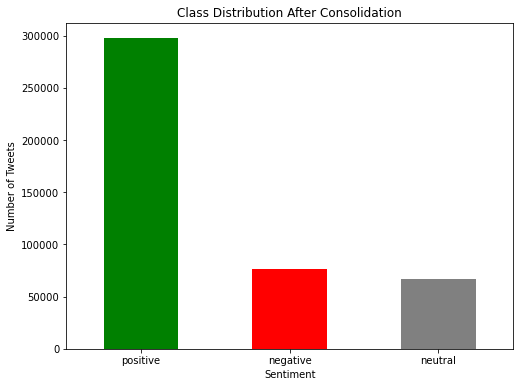

In [145]:
df['sentiment_consolidated'].value_counts().plot(kind='bar', color=['green', 'red', 'grey'])
plt.title('Class Distribution After Consolidation')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()


Class Imbalance

In [146]:
print("Counts:")
print(df['sentiment_consolidated'].value_counts())

print("\nProportions:")
print(df['sentiment_consolidated'].value_counts(normalize=True))


Counts:
sentiment_consolidated
positive    297457
negative     76566
neutral      67030
Name: count, dtype: int64

Proportions:
sentiment_consolidated
positive    0.674425
negative    0.173598
neutral     0.151977
Name: proportion, dtype: float64


There is class imbalance in the dataset as the tweet with sentiment positive are more than the negative and neutral.

Class Separability

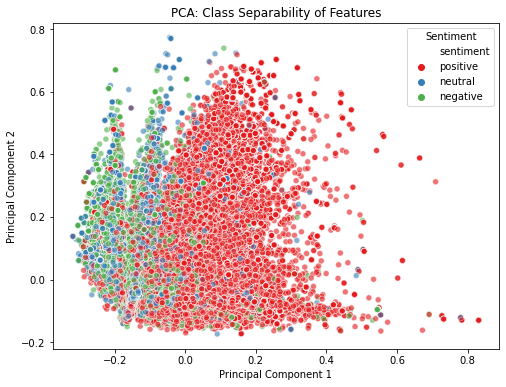

In [147]:
tf_vectorizer = TfidfVectorizer(max_features=500)
X = tf_vectorizer.fit_transform(df['clean_tweet'].fillna(''))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

# 2. Plot by class
df_pca = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'sentiment': df['sentiment_consolidated'].values
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='sentiment', palette='Set1', alpha=0.6)
plt.title('PCA: Class Separability of Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.show()

Feature Engineering

Adding tweet length into the dataframe

In [148]:
df['tweet_length'] = df['Tweet'].apply(len)

Counting the number of hashtags in the tweet

In [149]:
df['num_hashtags'] = df['Tweet'].apply(lambda x: len(re.findall(r"#\w+", x)))

In [150]:
pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())

In [151]:
def lexicon_score(text, pos_words, neg_words):
    tokens = text.split()
    pos = sum(1 for w in tokens if w in pos_words)
    neg = sum(1 for w in tokens if w in neg_words)
    return pos - neg

df['lexicon_score'] = df['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))


Encoding the label for classes positive, negative and neutral

In [152]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment_consolidated'])

In [153]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [154]:
df.tail()

,Tweet,Sentiment,word_count,punctuation_count,clean_tweet,tokens,sentiment_consolidated,tweet_length,num_hashtags,lexicon_score,label
451327,"Gaza; Peace n' Freedom - Viva Palestina convoy enters Algeria: \r\nThe Viva Palestina convoy, the massive relief c.. http://tinyurl.com/cajylt",Strong_Pos,19,12,gaza peace n freedom viva palestina convoy enters algeria viva palestina convoy massive relief c,"[gaza, peace, n, freedom, viva, palestina, convoy, enters, algeria, viva, palestina, convoy, massive, relief, c]",positive,140,0,3,2
451328,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CEN... http://tinyurl.com/dyth62 RT @freerepublic",Strong_Pos,19,14,face defense soldier find freedom fight freedom iraq convoy support cen rt,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, cen, rt]",positive,140,0,3,2
451329,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CENTER SCANIA, Iraq, .. http://tinyurl.com/dyth62",Strong_Pos,20,14,face defense soldier find freedom fight freedom iraq convoy support center scania iraq,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, center, scania, iraq]",positive,140,0,3,2
451330,"Gaza; Peace n' Freedom - ""Israel stops aid convoy en route to Gaza from Hebron"": \r\nMa&quot;an News Agency report.. http://tinyurl.com/7mguhc",Strong_Pos,20,15,gaza peace n freedom israel stop aid convoy en route gaza hebron quot news agency report,"[gaza, peace, n, freedom, israel, stop, aid, convoy, en, route, gaza, hebron, quot, news, agency, report]",positive,140,0,2,2
451331,@convoy 83 yes! get on freedom server!,Strong_Pos,7,3,yes get freedom server,"[yes, get, freedom, server]",positive,38,0,1,2


Splitting the data into training, validation and testing set

In [155]:
feature_cols = ['clean_tweet', 'tweet_length', 'num_hashtags', 'lexicon_score']
target_col = 'label'

X = df[feature_cols]
y = df[target_col]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

Exporting the preprocessed data into csv

In [158]:
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

y_train.to_frame().to_csv('../data/processed/y_train.csv', index=False)
y_val.to_frame().to_csv('../data/processed/y_val.csv', index=False)
y_test.to_frame().to_csv('../data/processed/y_test.csv', index=False)

Exporting the label encoder

In [157]:
with open('../model/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)